<a href="https://colab.research.google.com/github/fariha-experiments/Healthtech/blob/project%2Fbioinformatics-cancer/bioinformatics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
p_value = 0.05


In [ ]:
genes=["bcci","gmor","rtfs"]
for each in genes:
  print(f"i am {each}")

i am bcci
i am gmor
i am rtfs


In [ ]:
!pip install -q pandas scikit-learn matplotlib seaborn umap-learn




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("✅ All libraries and tools are ready!")



✅ All libraries and tools are ready!


In [ ]:
!wget -q ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE45nnn/GSE45827/matrix/GSE45827_series_matrix.txt.gz

In [ ]:
import gzip

file_path = 'GSE45827_series_matrix.txt.gz'

# Find the row number where the actual data table begins marker
idx_begin_marker = -1
with gzip.open(file_path, 'rt') as f: # 'rt' for reading as text
    for i, line in enumerate(f):
        if '!series_matrix_table_begin' in line:
            idx_begin_marker = i
            break

if idx_begin_marker == -1:
    # Fallback to a common skip row count if the marker isn't found.
    # This is a less robust approach but provides a default.
    num_rows_to_skip = 59
    print("Warning: '!series_matrix_table_begin' marker not found. Assuming a default skip of 59 rows.")
else:
    # The actual column headers are on the line immediately following '!series_matrix_table_begin'.
    # So, if '!series_matrix_table_begin' is at 0-indexed line 'idx_begin_marker',
    # then the header is at 'idx_begin_marker + 1'.
    # We need to skip all lines from 0 up to and including 'idx_begin_marker'.
    # Then the next line will be treated as the header (0-th row after skipping).
    num_rows_to_skip = idx_begin_marker + 1

data = pd.read_csv(
    file_path,
    compression='gzip',
    sep='\t',
    skiprows=num_rows_to_skip,
    header=0, # Use the first row after skipping `num_rows_to_skip` as the header
    index_col=0 # Use the first column of the header as index
)


In [ ]:
print(f"Dataset shape: {data.shape}")


Dataset shape: (29874, 155)


### ***data preprocessing and cleaning process below:***

In [ ]:
expression_data = data.T

# 2. Clean: Remove any rows or columns with missing values
expression_data = expression_data.dropna(axis=1, how='any')
expression_data = expression_data.dropna(axis=0, how='any')


In [ ]:
print(f"Cleaned dataset shape: {expression_data.shape}")


Cleaned dataset shape: (155, 29873)


In [ ]:
sample_ids = expression_data.index.tolist()
sample_char_dicts = {sample_id: {} for sample_id in sample_ids}

with gzip.open(file_path, 'rt') as f:
    metadata_lines = []
    for line in f:
        if line.startswith('!series_matrix_table_begin'):
            break
        if line.startswith('!'):
            metadata_lines.append(line.strip())

for line in metadata_lines:
    if line.startswith('!Sample_characteristics_ch1'):
        parts = line.split('\t')
        for i, sample_char_str in enumerate(parts[1:]):
            if i < len(sample_ids):
                sample_id = sample_ids[i]
                char_cleaned = sample_char_str.strip('"\n ')

                if ':' in char_cleaned:
                    key, value = char_cleaned.split(':', 1)
                    key = key.strip()
                    value = value.strip()
                    sample_char_dicts[sample_id][key] = value

characteristics_df = pd.DataFrame.from_dict(sample_char_dicts, orient='index')
characteristics_df = characteristics_df.reindex(sample_ids)

if 'subtype' in characteristics_df.columns:
    print("Characteristics:subtype data:")
    display(characteristics_df['subtype'])
else:
    print("No 'subtype' characteristic found in the metadata.")
    print("Available characteristics are:")
    display(characteristics_df.head())

# You can also add these characteristics to your expression_data DataFrame if needed
# expression_data = expression_data.join(characteristics_df)


No 'subtype' characteristic found in the metadata.
Available characteristics are:


,diagnosis,tumor subtype,batch,hybridation,cell line,cell origin
GSM1116084,Breast cancer,Basal,8,-1,NaN,NaN
GSM1116085,Breast cancer,Basal,8,-1,NaN,NaN
GSM1116086,Breast cancer,Her2,8,-1,NaN,NaN
GSM1116087,Breast cancer,Basal,8,-1,NaN,NaN
GSM1116088,Breast cancer,Her2,8,-1,NaN,NaN


In [ ]:
print("Columns in characteristics_df:")
display(characteristics_df.columns)

print("\nFirst 5 rows of characteristics_df:")
display(characteristics_df.head())

Columns in characteristics_df:


Index(['diagnosis', 'tumor subtype', 'batch', 'hybridation', 'cell line',
       'cell origin'],
      dtype='object')


First 5 rows of characteristics_df:


,diagnosis,tumor subtype,batch,hybridation,cell line,cell origin
GSM1116084,Breast cancer,Basal,8,-1,NaN,NaN
GSM1116085,Breast cancer,Basal,8,-1,NaN,NaN
GSM1116086,Breast cancer,Her2,8,-1,NaN,NaN
GSM1116087,Breast cancer,Basal,8,-1,NaN,NaN
GSM1116088,Breast cancer,Her2,8,-1,NaN,NaN


In [ ]:
y = characteristics_df['tumor subtype']
X = expression_data.copy() # Use a copy of expression_data for X

print("Shape of y (target variable):", y.shape)
print("First 5 values of y:\n", y.head())
print("\nShape of X (features):", X.shape)
print("First 5 columns of X:\n", X.head())

Shape of y (target variable): (155,)
First 5 values of y:
 GSM1116084    Basal
GSM1116085    Basal
GSM1116086     Her2
GSM1116087    Basal
GSM1116088     Her2
Name: tumor subtype, dtype: object

Shape of X (features): (155, 29873)
First 5 columns of X:
 ID_REF      1007_s_at  1053_at   117_at  1294_at  1316_at  1405_i_at  1438_at  \
GSM1116084    9.47065  8.36311  5.95426  6.02119  3.22997   10.82220  4.39698   
GSM1116085    9.67440  8.72194  7.02523  7.24581  3.29352    9.29455  6.68936   
GSM1116086   10.20800  7.78601  6.39671  6.85310  3.26204    9.45727  5.46440   
GSM1116087   10.11420  9.44537  4.56023  5.42786  3.34766   11.51270  5.29748   
GSM1116088   11.16360  7.71242  5.29008  7.51120  3.59086    8.83075  6.81821   

ID_REF      1487_at  1552256_a_at  1552257_a_at  ...  87100_at  89476_r_at  \
GSM1116084  6.65320      10.91320      10.07510  ...   3.90703     7.67662   
GSM1116085  7.20820       9.32204       9.34476  ...   5.84253     7.32080   
GSM1116086  6.68974      

In [ ]:
print(characteristics_df)

                diagnosis tumor subtype batch hybridation cell line  \
GSM1116084  Breast cancer         Basal     8          -1       NaN   
GSM1116085  Breast cancer         Basal     8          -1       NaN   
GSM1116086  Breast cancer          Her2     8          -1       NaN   
GSM1116087  Breast cancer         Basal     8          -1       NaN   
GSM1116088  Breast cancer          Her2     8          -1       NaN   
...                   ...           ...   ...         ...       ...   
GSM1116234  Breast cancer     Luminal A     5           3       NaN   
GSM1116235  Breast cancer     Luminal A     5           3       NaN   
GSM1116236  Breast cancer     Luminal B     5           3       NaN   
GSM1116237  Breast cancer     Luminal B     5           3       NaN   
GSM1116238  Breast cancer     Luminal B     5           3       NaN   

           cell origin  
GSM1116084         NaN  
GSM1116085         NaN  
GSM1116086         NaN  
GSM1116087         NaN  
GSM1116088         NaN

there was an error to copy subtype to a different table. hence we dropeed the "drop" line after separating subtype to y

In [ ]:
encoder = LabelEncoder()

# Transform the 'y' labels
y_encoded = encoder.fit_transform(y)

# Let's see the mapping
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Label mapping:", label_mapping)


Label mapping: {'Basal': np.int64(0), 'Her2': np.int64(1), 'Luminal A': np.int64(2), 'Luminal B': np.int64(3), 'N/A': np.int64(4), nan: np.int64(5)}


we're assigning a numerical value to "string" type data for future ml operations

In [ ]:
scaler = StandardScaler()

# Fit the scaler to the features and transform them
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame for easier handling
X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

print("Feature standardization complete.")


Feature standardization complete.


In [ ]:
pca = PCA(n_components=2)  # Reduce to 2 principal components
pca_result = pca.fit_transform(X_scaled)

print(pca_result.shape)

(155, 2)


In [ ]:
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=X_scaled.index)
pca_df['tumor subtype'] = y

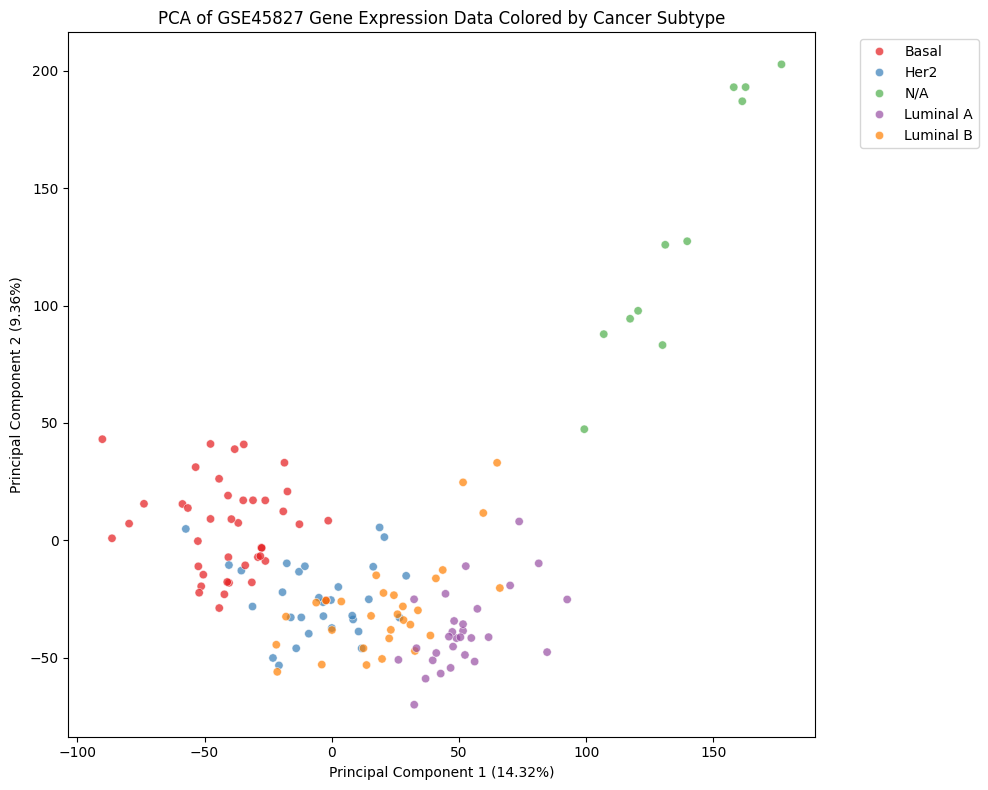

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='tumor subtype', palette='Set1', alpha=0.7)
plt.title('PCA of GSE45827 Gene Expression Data Colored by Cancer Subtype')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 124 samples
Test set size: 31 samples


Basically, here we prepare two sets of data - **testing** dataset and **training dataset** .
training is about 80% of the original, scaled dataset and testing is 20%. the testing data is separated to form separately so it acts as a new, unseen data for the model to perform on to verify it's o/p behavior.

In [ ]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_clf.predict(X_test)


In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}\n")


Model Accuracy: 96.77%



In [ ]:
print("Classification Report:")

# Filter out np.nan from encoder.classes_ before passing to target_names
import numpy as np
import pandas as pd

filtered_target_names = [name for name in encoder.classes_ if pd.notna(name)]

# Get the corresponding numerical labels for the filtered target names
# Assuming that the encoder.classes_ maintains order, the labels will be 0, 1, 2, 3, 4
filtered_labels = [i for i, name in enumerate(encoder.classes_) if pd.notna(name)]

print(classification_report(y_test, y_pred, labels=filtered_labels, target_names=filtered_target_names))

Classification Report:
              precision    recall  f1-score   support

       Basal       0.89      1.00      0.94         8
        Her2       1.00      0.83      0.91         6
   Luminal A       1.00      1.00      1.00         6
   Luminal B       1.00      1.00      1.00         6
         N/A       1.00      1.00      1.00         2

   micro avg       0.96      0.96      0.96        28
   macro avg       0.98      0.97      0.97        28
weighted avg       0.97      0.96      0.96        28



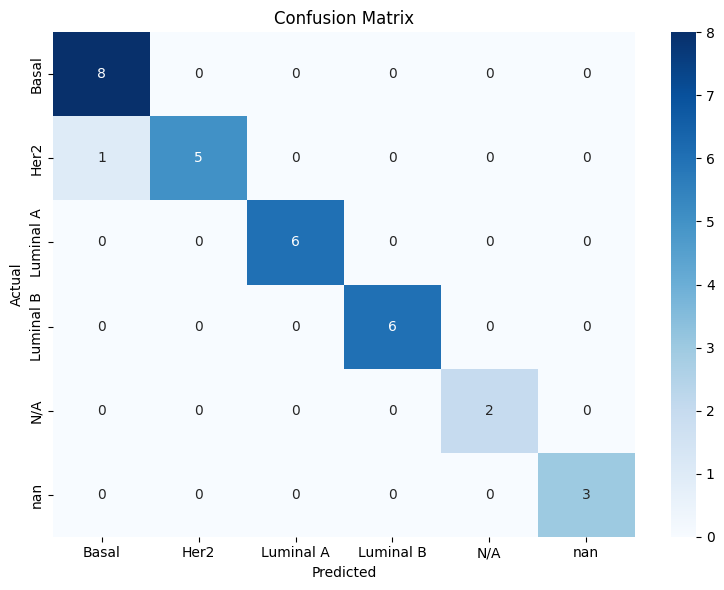

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


we're visualising the most important genes predicting the subtype of cancer

/tmp/ipykernel_2274/2535998861.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp.head(15).values, y=feature_imp.head(15).index, palette='viridis')


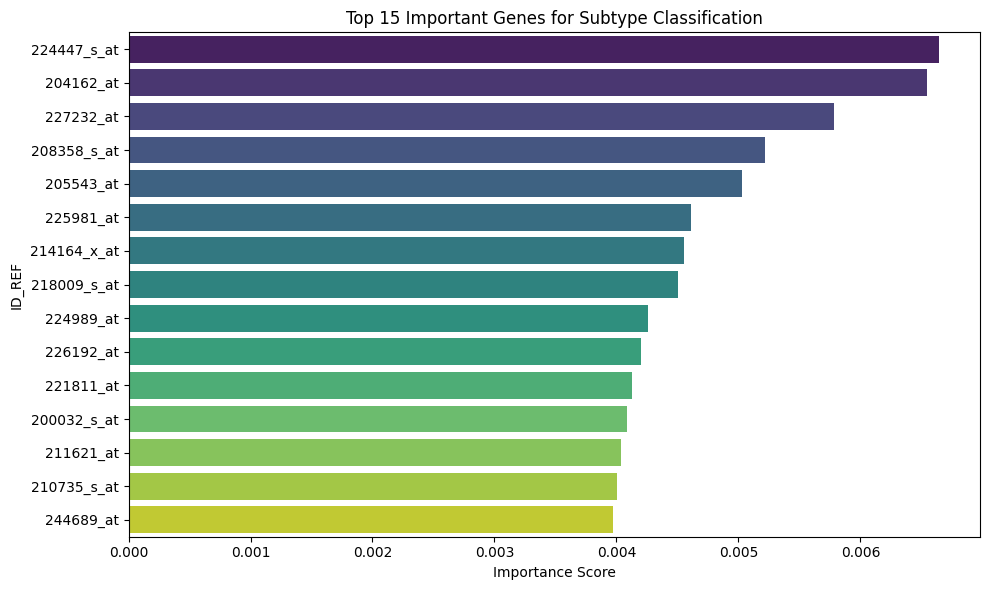

In [ ]:
importances = rf_clf.feature_importances_

# Create a Series to sort features by importance
feature_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Plot the top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.head(15).values, y=feature_imp.head(15).index, palette='viridis')
plt.title('Top 15 Important Genes for Subtype Classification')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


### Explanation of the PCA Plot Error (Empty Plot)

**The Problem: Index Mismatch**

The `sns.scatterplot` was empty because the 'tumor subtype' column in `pca_df` contained `NaN` (Not a Number) values. This happened during the assignment:

```python
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['tumor subtype'] = y
```

Initially, `pca_df` was created with a default `RangeIndex` (0, 1, 2, ...), while `y` (your 'tumor subtype' Series) had sample IDs (e.g., 'GSM1116084') as its index. When you tried to assign `y` to a new column in `pca_df`, pandas attempted to align these two DataFrames/Series based on their indices. Since there was no common index between the default `RangeIndex` of `pca_df` and the sample ID index of `y`, all values in the 'tumor subtype' column of `pca_df` became `NaN`.

**Conceptual View of the `pca_df` BEFORE the fix:**

| Index | PC1      | PC2      | tumor subtype |
|-------|----------|----------|---------------|
| 0     | -79.669  | 7.116    | NaN           |
| 1     | -52.635  | -0.323   | NaN           |
| 2     | 8.377    | -33.714  | NaN           |
| ...   | ...      | ...      | ...           |

**Conceptual View of `y`:**

| Index      | tumor subtype |
|------------|---------------|
| GSM1116084 | Basal         |
| GSM1116085 | Basal         |
| GSM1116086 | Her2          |
| ...        | ...           |


**The Solution: Aligning Indices**

The fix involved creating `pca_df` with the correct index from `X_scaled`, which matches the index of `y`:

```python
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=X_scaled.index)
pca_df['tumor subtype'] = y
```

By setting `index=X_scaled.index` when creating `pca_df`, its index now aligns with the index of `y`. This allows the 'tumor subtype' values from `y` to be correctly mapped to the corresponding rows in `pca_df`.

**Conceptual View of the `pca_df` AFTER the fix:**

| Index      | PC1      | PC2      | tumor subtype |
|------------|----------|----------|---------------|
| GSM1116084 | -79.669  | 7.116    | Basal         |
| GSM1116085 | -52.635  | -0.323   | Basal         |
| GSM1116086 | 8.377    | -33.714  | Her2          |
| ...        | ...      | ...      | ...           |

With the correct 'tumor subtype' values, the `sns.scatterplot` can now properly color the points based on their respective subtypes.

## Resources

### Dataset Information
*   **GEO Accession:** GSE45827
*   **Platform:** GPL6947 Illumina HumanRef-8 v3.0 expression beadchip
*   **Description:** Gene expression profiles of ... (add specific details about the dataset, e.g., organism, tissue, disease state).
*   **Citation:** (If applicable, add citation information for the dataset or its source publication.)

### Data Processing Notes
*   Initial data downloaded from NCBI GEO.
*   Skipped header rows containing general series metadata using the `!series_matrix_table_begin` marker.
*   Sample characteristics (e.g., 'subtype') extracted separately from the file's metadata sections.

### Handling `NaN` in Target Variable (`tumor subtype`)

In the `tumor subtype` target variable, we encountered `NaN` values. The `LabelEncoder` treated these `NaN`s as a distinct class, encoding them into a numerical label (e.g., `5`). This means the model was trained to predict this `NaN` class.

For the purpose of evaluation and reporting using `classification_report`, we have implemented a filter to:
1.  Exclude `np.nan` from the `target_names` display list.
2.  Specify `labels` to the `classification_report` to ensure only the meaningful, non-NaN classes are included in the report, preventing a mismatch error.

This approach allows the model to leverage all data during training (even samples with an 'unknown' subtype) while providing a clean, interpretable classification report focusing on the biologically relevant tumor subtypes.